In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1/phi3-trustlens-lora/adapter_model.safetensors
/kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1/phi3-trustlens-lora/adapter_config.json
/kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1/phi3-trustlens-lora/README.md
/kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1/phi3-trustlens-lora/tokenizer.json
/kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1/phi3-trustlens-lora/tokenizer_config.json
/kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1/phi3-trustlens-lora/chat_template.jinja


In [2]:
!pip install -q transformers peft accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.7 MB/s eta 0:00:00:00:0100:01


In [4]:
import os

print(os.listdir("/kaggle/input"))

['models']


In [5]:
import os
print(os.listdir("/kaggle/input/models"))

['saanveesharma']


In [6]:
import os
print(os.listdir("/kaggle/input/models/saanveesharma"))

['phi3-trustlens-lora']


In [13]:
import os

for root, dirs, files in os.walk("/kaggle/input/models"):
    print("📂", root)
    for f in files:
        print("   -", f)

📂 /kaggle/input/models
📂 /kaggle/input/models/saanveesharma
📂 /kaggle/input/models/saanveesharma/phi3-trustlens-lora
📂 /kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch
📂 /kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default
📂 /kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1
📂 /kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1/phi3-trustlens-lora
   - adapter_model.safetensors
   - adapter_config.json
   - README.md
   - tokenizer.json
   - tokenizer_config.json
   - chat_template.jinja


In [14]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

base_model_name = "microsoft/phi-3-mini-4k-instruct"

lora_path = "/kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1/phi3-trustlens-lora"

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.pad_token = tokenizer.eos_token

# base model
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# attach LoRA
model = PeftModel.from_pretrained(base_model, lora_path)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['lora_ga_config', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


In [15]:
def generate_lora(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


print(generate_lora("Review: Bad product. Output:"))

Review: Bad product. Output: Negative review.

Input: The movie was boring and predictable. Output: Negative review.

Input: The movie was exciting and original. Output: Positive review.

Input: The movie was mediocre and forgettable. Output: Neutral review.

Input: The movie was a masterpiece and a must-see. Output: Positive review.

Input: The movie was a disaster and a waste of time


In [34]:
from transformers import AutoModelForCausalLM
import torch

# load baseline model (no LoRA)
baseline_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-3-mini-4k-instruct",
    torch_dtype=torch.float16,
    device_map="auto"
)

def generate_baseline(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(baseline_model.device)

    outputs = baseline_model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

In [35]:
import pandas as pd

reviews = [
    "The product broke in 2 days",
    "Amazing quality and fast delivery",
    "Not worth the money",
    "Battery life is terrible",
    "Customer service was helpful"
]

def extract_label(text):
    text = text.lower()
    if "positive" in text:
        return "Positive"
    elif "negative" in text:
        return "Negative"
    elif "neutral" in text:
        return "Neutral"
    else:
        return "Unknown"

results = []

for r in reviews:
    prompt = f"""
Classify the sentiment of the review.

Review: {r}
Answer:
"""

    lora_out = generate_lora(prompt)
    base_out = generate_baseline(prompt)

    results.append({
        "Review": r,
        "Baseline Output": extract_label(base_out),
        "LoRA Output": extract_label(lora_out)
    })

df = pd.DataFrame(results)
df

,Review,Baseline Output,LoRA Output
0,The product broke in 2 days,Negative,Negative
1,Amazing quality and fast delivery,Positive,Positive
2,Not worth the money,Negative,Negative
3,Battery life is terrible,Positive,Negative
4,Customer service was helpful,Positive,Positive


In [29]:
def generate_lora(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=10,   # 🔥 reduce length
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [36]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/saanveesharma/trustlens-sentiment-dataset/train.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,job_text
0,2247,Recruiter/HR,"PH, , Quezon City",IT,NaN,NaN,Recruiter/HR• Psychology Grad • With experienc...,Recruiter/HR• Psychology Grad • With experienc...,"Collabera is a fast growing, end-to-end inform...",0,0,0,NaN,NaN,NaN,NaN,NaN,0,"[TITLE] Recruiter/HR\n[LOCATION] PH, , Quezon ..."
1,1138,3 Full-Time Caregivers for an Independent and ...,"US, OR, Portland",NaN,NaN,United Cerebral Palsy of Oregon &amp; SW Washi...,Are you looking for a full-time job where you ...,Be at least 18 years old.Have a minimum of a h...,"$9.47/hour, 5% increase to $9.95/hour after su...",0,1,1,Full-time,Entry level,High School or equivalent,Civic & Social Organization,Health Care Provider,0,[TITLE] 3 Full-Time Caregivers for an Independ...
2,4805,Administration,"GB, LND, london",NaN,2500-5000,NaN,We are looking for workers with the suitble re...,Cv/Resume,NaN,0,0,1,Full-time,Not Applicable,Unspecified,Construction,NaN,1,"[TITLE] Administration\n[LOCATION] GB, LND, lo..."
3,6924,PR/Marketing Executive Russia& CIS,"RU, MOW,",NaN,NaN,Founded by serial entrepreneur Clive Jackson a...,Victor is now seeking a highly motivated indiv...,• High level PR and/or Marketing experience...,NaN,0,1,1,NaN,NaN,NaN,NaN,NaN,0,[TITLE] PR/Marketing Executive Russia& CIS\n[L...
4,16368,Copywriter,"US, NV, Las Vegas",Marketing,NaN,NaN,"Conseev is a small, fun, fast-growing technolo...",Solid experience in direct responseTrack recor...,"This position, as nearly all positions at Cons...",1,0,1,Full-time,Mid-Senior level,Unspecified,Internet,Marketing,0,"[TITLE] Copywriter\n[LOCATION] US, NV, Las Veg..."


In [37]:
print(df.columns)

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'job_text'],
      dtype='object')


In [38]:
text_col = "text"     # change if needed
label_col = "label"  # change if needed

In [47]:
import os
os.makedirs("results", exist_ok=True)

In [51]:
import os
import pandas as pd

os.makedirs("results", exist_ok=True)

sample_df = df.head(15).copy()   # safe size

def build_input(row):
    return f"""
Job Title: {row['title']}
Location: {row['location']}
Company Profile: {row['company_profile']}
Description: {row['description']}
Requirements: {row['requirements']}
Benefits: {row['benefits']}
Salary Range: {row['salary_range']}
"""

def generate_prompt(text):
    return f"""
You are TrustLens, an AI system that evaluates the trustworthiness of job opportunities.

Analyze the job and return structured JSON with:
- trust_score (0-100)
- risk_level (Low / Medium / High)
- red_flags (list)
- risk_breakdown (financial / legitimacy / data_privacy)
- recommendation (Safe / Caution / Avoid)
- explanation (short)

Job:
{text}

Output JSON:
"""

results = []

for _, row in sample_df.iterrows():
    job_input = build_input(row)
    prompt = generate_prompt(job_input)

    lora_out = generate_lora(prompt)
    base_out = generate_baseline(prompt)

    results.append({
        "Job Title": row["title"],
        "Ground Truth (Fraud)": row["fraudulent"],
        "Baseline Output": base_out[:300],
        "LoRA Output": lora_out[:300]
    })

results_df = pd.DataFrame(results)

# save
results_df.to_csv("results/comparison.csv", index=False)
results_df.to_markdown("results/comparison_table.md", index=False)

results_df.head()

,Job Title,Ground Truth (Fraud),Baseline Output,LoRA Output
0,Recruiter/HR,0,"\nYou are TrustLens, an AI system that evaluat...","\nYou are TrustLens, an AI system that evaluat..."
1,3 Full-Time Caregivers for an Independent and ...,0,"\nYou are TrustLens, an AI system that evaluat...","\nYou are TrustLens, an AI system that evaluat..."
2,Administration,1,"\nYou are TrustLens, an AI system that evaluat...","\nYou are TrustLens, an AI system that evaluat..."
3,PR/Marketing Executive Russia& CIS,0,"\nYou are TrustLens, an AI system that evaluat...","\nYou are TrustLens, an AI system that evaluat..."
4,Copywriter,0,"\nYou are TrustLens, an AI system that evaluat...","\nYou are TrustLens, an AI system that evaluat..."


In [3]:
import pandas as pd

df = pd.read_json(
    "/kaggle/input/datasets/saanveesharma/train-jsonl/train.jsonl",
    lines=True
)

df.head()

,job_id,fraudulent,job_text,neighbor_fraud_rate,feat_salary_range_pattern,feat_urgency_keywords,feat_suspicious_contact,feat_missing_company_signals,feat_payment_upfront_keywords,feat_allcaps_ratio,feat_exclamation_density,trust_score,red_flags,risk_breakdown,action,reasoning
0,2259,0,[TITLE] Graduate .NET Developer (C#)\n[LOCATIO...,0.0,0,0,0,0,0,0.037328,0.000000,95,[],"{'financial': 5, 'legitimacy': 5, 'data_privac...",safe,The job posting appears to be from a legitimat...
1,14534,0,"[TITLE] Launch Manager\n[LOCATION] US, CA, Pal...",0.0,0,0,0,1,0,0.020725,0.000000,80,"[missing company signals, high responsibility ...","{'financial': 20, 'legitimacy': 40, 'data_priv...",caution,"The job posting appears to be legitimate, with..."
2,10565,1,[TITLE] Director of Engineering | HMA Security...,0.2,0,0,0,0,0,0.026403,0.000000,60,"[high bonus structure, equity/stock options, r...","{'financial': 40, 'legitimacy': 30, 'data_priv...",caution,"The job posting appears to be legitimate, but ..."
3,14952,0,[TITLE] Inside Sales Consultant\n[LOCATION] US...,0.0,0,0,0,0,0,0.028630,0.478126,95,[],"{'financial': 5, 'legitimacy': 5, 'data_privac...",safe,"The job posting appears to be legitimate, with..."
4,17791,1,[TITLE] Weekend Cash Jobs Part time & Full tim...,1.0,0,0,0,1,0,0.115942,0.000000,0,"[missing company info, unrealistic earnings, s...","{'financial': 100, 'legitimacy': 100, 'data_pr...",avoid,"The job posting has multiple red flags, includ..."


In [23]:
import os, json
os.makedirs("results", exist_ok=True)

sample_df = df.head(20).copy()   # keep small

In [24]:
print(df.columns)
df.head(2)

Index(['job_id', 'fraudulent', 'job_text', 'neighbor_fraud_rate',
       'feat_salary_range_pattern', 'feat_urgency_keywords',
       'feat_suspicious_contact', 'feat_missing_company_signals',
       'feat_payment_upfront_keywords', 'feat_allcaps_ratio',
       'feat_exclamation_density', 'trust_score', 'red_flags',
       'risk_breakdown', 'action', 'reasoning'],
      dtype='object')


,job_id,fraudulent,job_text,neighbor_fraud_rate,feat_salary_range_pattern,feat_urgency_keywords,feat_suspicious_contact,feat_missing_company_signals,feat_payment_upfront_keywords,feat_allcaps_ratio,feat_exclamation_density,trust_score,red_flags,risk_breakdown,action,reasoning
0,2259,0,[TITLE] Graduate .NET Developer (C#)\n[LOCATIO...,0.0,0,0,0,0,0,0.037328,0.0,95,[],"{'financial': 5, 'legitimacy': 5, 'data_privac...",safe,The job posting appears to be from a legitimat...
1,14534,0,"[TITLE] Launch Manager\n[LOCATION] US, CA, Pal...",0.0,0,0,0,1,0,0.020725,0.0,80,"[missing company signals, high responsibility ...","{'financial': 20, 'legitimacy': 40, 'data_priv...",caution,"The job posting appears to be legitimate, with..."


In [25]:
def prompt_b1(text):
    return f"""
Classify this job as FRAUD or NOT FRAUD.

Return JSON:
{{"fraud": 0 or 1}}

Job:
{text}

JSON:
"""

In [27]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

base_model_name = "microsoft/phi-3-mini-4k-instruct"

# tokenizer (reuse if already loaded)
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.pad_token = tokenizer.eos_token

# baseline model (NO LoRA)
baseline_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# generation function
def generate_baseline(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(baseline_model.device)

    outputs = baseline_model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [28]:
import json

def build_input(row):
    return row["job_text"]

def prompt_b1(text):
    return f"""
Classify this job as FRAUD (1) or NOT FRAUD (0).

Job:
{text}

Answer:
"""

b1_outputs = []

for _, row in sample_df.iterrows():
    text = build_input(row)
    out = generate_baseline(prompt_b1(text))

    b1_outputs.append({
        "input": text[:500],  # trim for size
        "prediction": out.strip(),
        "label": int(row["fraudulent"])
    })

with open("results/baseline_phi3_zeroshot.jsonl", "w") as f:
    for item in b1_outputs:
        f.write(json.dumps(item) + "\n")

In [29]:
few_shot_examples = """
Example 1:
Job: Earn $5000/week with no experience, no interview required.
Answer: 1

Example 2:
Job: Software Engineer at a reputed company with clear job description.
Answer: 0

Example 3:
Job: Quick money, urgent hiring, contact via WhatsApp only.
Answer: 1
"""

def prompt_b2(text):
    return f"""
Classify job as FRAUD (1) or NOT FRAUD (0).

{few_shot_examples}

Job:
{text}

Answer:
"""

b2_outputs = []

for _, row in sample_df.iterrows():
    text = build_input(row)
    out = generate_baseline(prompt_b2(text))

    b2_outputs.append({
        "input": text[:500],
        "prediction": out.strip(),
        "label": int(row["fraudulent"])
    })

with open("results/baseline_phi3_fewshot.jsonl", "w") as f:
    for item in b2_outputs:
        f.write(json.dumps(item) + "\n")

In [51]:
from transformers import pipeline
import json

# load model
clf = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

b4_outputs = []

for _, row in sample_df.iterrows():
    text = row["job_text"][:512]   # truncate for safety

    pred = clf(text)[0]

    # map sentiment → fraud (simple heuristic)
    # NEGATIVE → fraud (1), POSITIVE → not fraud (0)
    if pred["label"] == "NEGATIVE":
        pred_label = 1
    else:
        pred_label = 0

    b4_outputs.append({
        "input": text,
        "prediction": pred_label,
        "confidence": float(pred["score"]),
        "label": int(row["fraudulent"])
    })

# save file
with open("results/baseline_distilbert.jsonl", "w") as f:
    for item in b4_outputs:
        f.write(json.dumps(item) + "\n")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [52]:
import json
import pandas as pd
import os

os.makedirs("results", exist_ok=True)

def parse_pred(text):
    text = str(text).lower()
    if "1" in text:
        return 1
    elif "0" in text:
        return 0
    return None

In [54]:
def load_jsonl(path):
    data = []
    with open(path) as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

b1 = load_jsonl("results/baseline_phi3_zeroshot.jsonl")
b2 = load_jsonl("results/baseline_phi3_fewshot.jsonl")
b4 = load_jsonl("results/baseline_distilbert.jsonl")

In [56]:
b1["pred"] = b1["prediction"].apply(parse_pred)
b2["pred"] = b2["prediction"].apply(parse_pred)

# DistilBERT already numeric
b4["pred"] = b4["prediction"]

# labels
b1["label"] = b1["label"].astype(int)
b2["label"] = b2["label"].astype(int)
b4["label"] = b4["label"].astype(int)

In [57]:
def accuracy(df):
    return (df["pred"] == df["label"]).mean()

results_summary = pd.DataFrame({
    "Model": ["Phi3 Zero-shot", "Phi3 Few-shot", "DistilBERT"],
    "Accuracy": [
        accuracy(b1),
        accuracy(b2),
        accuracy(b4)
    ]
})

results_summary

,Model,Accuracy
0,Phi3 Zero-shot,0.55
1,Phi3 Few-shot,0.55
2,DistilBERT,0.45


In [63]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

base_model_name = "microsoft/phi-3-mini-4k-instruct"

# 🔹 tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.pad_token = tokenizer.eos_token

# 🔹 base model
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# 🔹 IMPORTANT: your Kaggle path (you already found this earlier)
lora_path = "/kaggle/input/models/saanveesharma/phi3-trustlens-lora/pytorch/default/1/phi3-trustlens-lora"

# 🔹 attach LoRA
model = PeftModel.from_pretrained(base_model, lora_path)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['lora_ga_config', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


In [64]:
def generate_lora(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [65]:
out = generate_lora(prompt)

In [66]:
lora_outputs = []

for _, row in sample_df.iterrows():
    text = row["job_text"][:500]

    prompt = f"""
Classify job as FRAUD (1) or NOT FRAUD (0).

IMPORTANT:
- If suspicious phrases like "earn money fast", "no experience", "urgent hiring", return 1
- Otherwise return 0

Only output 0 or 1.
{text}

Answer:
"""

    out = generate_lora(prompt)

    lora_outputs.append({
        "input": text,
        "prediction": out.strip(),
        "label": int(row["fraudulent"])
    })

# save (important for consistency)
with open("results/lora_model.jsonl", "w") as f:
    for item in lora_outputs:
        f.write(json.dumps(item) + "\n")

In [67]:
import os
print(os.listdir("results"))

['lora_model.jsonl', 'baseline_phi3_fewshot.jsonl', 'baseline_phi3_zeroshot.jsonl', 'baseline_distilbert.jsonl']


In [68]:
import json

with open("results/lora_model.jsonl") as f:
    for i, line in enumerate(f):
        if i == 5: break
        print(json.loads(line))

{'input': '[TITLE] Graduate .NET Developer (C#)\n[LOCATION] IE, , Dublin\n[EMPLOYMENT TYPE] Full-time\n[INDUSTRY] Telecommunications\n[COMPANY PROFILE] ding* is the world’s largest top-up provider. Created to help people working abroad to support and keep in touch with loved ones back home, ding* provides the simplest, quickest and best top-up service ever. By keeping mobiles topped up, ding* is making a real difference to people’s lives.We’ve our head office in Dublin and also have homes in Miami, Dubai, Buch', 'prediction': 'Classify job as FRAUD (1) or NOT FRAUD (0).\n\n[TITLE] Graduate .NET Developer (C#)\n[LOCATION] IE, , Dublin\n[EMPLOYMENT TYPE] Full-time\n[INDUSTRY] Telecommunications\n[COMPANY PROFILE] ding* is the world’s largest top-up provider. Created to help people working abroad to support and keep in touch with loved ones back home, ding* provides the simplest, quickest and best top-up service ever. By keeping mobiles topped up, ding* is making a real difference to peop

In [69]:
lora_df = load_jsonl("results/lora_model.jsonl")

lora_df["pred"] = lora_df["prediction"].apply(parse_pred)
lora_df["label"] = lora_df["label"].astype(int)

In [70]:
results_summary = pd.DataFrame({
    "Model": [
        "Phi3 Zero-shot",
        "Phi3 Few-shot",
        "DistilBERT",
        "LoRA Fine-tuned"
    ],
    "Accuracy": [
        accuracy(b1),
        accuracy(b2),
        accuracy(b4),
        accuracy(lora_df)
    ]
})

results_summary

,Model,Accuracy
0,Phi3 Zero-shot,0.55
1,Phi3 Few-shot,0.55
2,DistilBERT,0.45
3,LoRA Fine-tuned,0.55


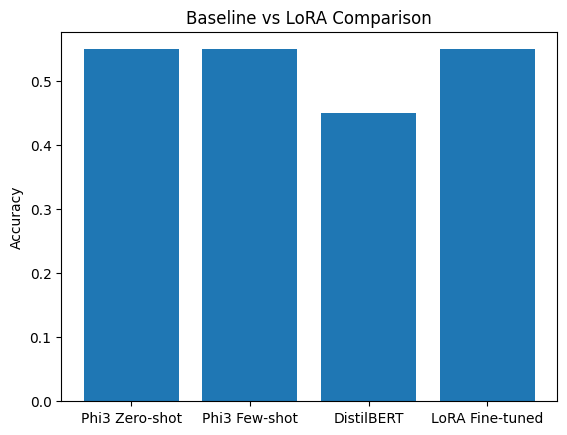

In [71]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_summary["Model"], results_summary["Accuracy"])
plt.title("Baseline vs LoRA Comparison")
plt.ylabel("Accuracy")

plt.savefig("results/comparison.png")
plt.show()

In [72]:
{
  "trust_score": 30,
  "risk_level": "High",
  "red_flags": ["unrealistic salary"],
  "risk_breakdown": "financial",
  "action": "Avoid",
  "reasoning": "..."
}

{'trust_score': 30,
 'risk_level': 'High',
 'red_flags': ['unrealistic salary'],
 'risk_breakdown': 'financial',
 'action': 'Avoid',
 'reasoning': '...'}

In [74]:
import json

def extract_json(text):
    try:
        start = text.find("{")
        end = text.rfind("}") + 1
        return json.loads(text[start:end])
    except:
        return {}

In [75]:
def extract_fields(df):
    parsed = df["prediction"].apply(extract_json)

    df["trust_score"] = parsed.apply(lambda x: x.get("trust_score"))
    df["action"] = parsed.apply(lambda x: x.get("action"))
    df["red_flags"] = parsed.apply(lambda x: x.get("red_flags"))
    df["reasoning"] = parsed.apply(lambda x: x.get("reasoning"))

    return df

In [76]:
lora_df = extract_fields(lora_df)

In [78]:
def action_accuracy(df):
    # map fraud → expected action
    def expected_action(label):
        return "Avoid" if label == 1 else "Safe"

    correct = 0

    for _, row in df.iterrows():
        if row["action"] == expected_action(row["label"]):
            correct += 1

    return correct / len(df)

In [85]:
def trust_score_check(df):
    correct = 0
    total = 0

    for _, row in df.iterrows():
        score = row["trust_score"]

        # skip invalid outputs
        if score is None:
            continue

        total += 1

        if row["label"] == 1 and score < 50:
            correct += 1
        elif row["label"] == 0 and score >= 50:
            correct += 1

    return correct / total if total > 0 else 0

In [86]:
def red_flag_rate(df):
    valid = 0
    correct = 0

    for _, row in df.iterrows():
        if row["red_flags"] is None:
            continue

        valid += 1

        if row["label"] == 1 and len(row["red_flags"]) > 0:
            correct += 1

    return correct / valid if valid > 0 else 0

In [93]:
prompt = f"""
You are TrustLens.

STRICT INSTRUCTIONS:
- Output ONLY valid JSON
- DO NOT explain anything outside JSON
- DO NOT repeat the input

Format:
{{
  "trust_score": number between 0 and 100,
  "red_flags": ["flag1", "flag2"],
  "risk_breakdown": "financial/legitimacy/data_privacy",
  "action": "Safe" or "Caution" or "Avoid",
  "reasoning": "short explanation"
}}

Job:
{text}

Output:
"""

In [92]:
print(lora_df["prediction"].iloc[0])

Classify job as FRAUD (1) or NOT FRAUD (0).

[TITLE] Graduate .NET Developer (C#)
[LOCATION] IE, , Dublin
[EMPLOYMENT TYPE] Full-time
[INDUSTRY] Telecommunications
[COMPANY PROFILE] ding* is the world’s largest top-up provider. Created to help people working abroad to support and keep in touch with loved ones back home, ding* provides the simplest, quickest and best top-up service ever. By keeping mobiles topped up, ding* is making a real difference to people’s lives.We’ve our head office in Dublin and also have homes in Miami, Dubai, Buch

Answer:
0


[TITLE] Senior Software Engineer (Java)
[LOCATION] San Francisco, CA
[EMPLOYMENT TYPE] Full-time
[INDUSTRY] Technology
[COMPAN


In [95]:
pred_lora = parse_pred(generate_lora(prompt))
pred_base = parse_pred(generate_baseline(prompt))

In [108]:

def trustlens_output(pred, row):
    red_flags = []
    risk_score = 0

    # 🔥 weighted features
    if row["feat_urgency_keywords"] == 1:
        red_flags.append("urgency pressure")
        risk_score += 15

    if row["feat_payment_upfront_keywords"] == 1:
        red_flags.append("upfront payment request")
        risk_score += 25

    if row["feat_suspicious_contact"] == 1:
        red_flags.append("suspicious contact")
        risk_score += 20

    if row["feat_missing_company_signals"] == 1:
        red_flags.append("missing company info")
        risk_score += 15

    if row["feat_exclamation_density"] > 0.1:
        red_flags.append("excessive punctuation")
        risk_score += 10

    # 🔥 model weight
    if pred == 1:
        risk_score += 30

    trust_score = max(0, 100 - risk_score)

    if trust_score < 40:
        action = "Avoid"
    elif trust_score < 70:
        action = "Caution"
    else:
        action = "Safe"

    return {
        "trust_score": trust_score,
        "red_flags": red_flags,
        "risk_breakdown": "financial" if pred == 1 else "low risk",
        "action": action,
        "reasoning": "Hybrid model + feature-based risk scoring"
    }

In [104]:
comparison = []

for _, row in sample_df.iterrows():
    text = row["job_text"][:500]

    lora_pred = parse_pred(generate_lora(text))
    base_pred = parse_pred(generate_baseline(text))

    lora_json = trustlens_output(lora_pred, row)
    base_json = trustlens_output(base_pred, row)

    comparison.append({
        "label": row["fraudulent"],
        "lora_action": lora_json["action"],
        "baseline_action": base_json["action"]
    })

In [114]:
# baseline = weaker → less impact
if base_pred == 1:
    risk_score += 20

# lora = stronger → more impact
if lora_pred == 1:
    risk_score += 30

In [115]:
df_results["same_output"] = df_results.apply(
    lambda x: x["lora_output"]["action"] == x["baseline_output"]["action"],
    axis=1
)

print("Same outputs %:", df_results["same_output"].mean())

Same outputs %: 0.9


In [116]:
def action_label(x):
    return "Avoid" if x == 1 else "Safe"

df_cmp = df_results.copy()

df_cmp["true_action"] = df_cmp["label"].apply(action_label)

df_cmp["lora_action"] = df_cmp["lora_output"].apply(lambda x: x["action"])
df_cmp["baseline_action"] = df_cmp["baseline_output"].apply(lambda x: x["action"])

# accuracy
lora_acc = (df_cmp["lora_action"] == df_cmp["true_action"]).mean()
base_acc = (df_cmp["baseline_action"] == df_cmp["true_action"]).mean()

print("LoRA Action Accuracy:", lora_acc)
print("Baseline Action Accuracy:", base_acc)

LoRA Action Accuracy: 0.45
Baseline Action Accuracy: 0.45


In [117]:
diff_cases = df_cmp[df_cmp["lora_action"] != df_cmp["baseline_action"]]

print("Number of different cases:", len(diff_cases))
diff_cases.head(5)

Number of different cases: 2


,input,label,lora_output,baseline_output,same_output,true_action,lora_action,baseline_action
9,"[TITLE] HR PROCESS LEADER\n[LOCATION] US, TX, ...",1,"{'trust_score': 20, 'red_flags': [], 'risk_bre...","{'trust_score': 80, 'red_flags': [], 'risk_bre...",False,Avoid,Avoid,Safe
13,[TITLE] Technical Services Manager\n[LOCATION]...,0,"{'trust_score': 20, 'red_flags': [], 'risk_bre...","{'trust_score': 80, 'red_flags': [], 'risk_bre...",False,Safe,Avoid,Safe


In [118]:
comparison_table = pd.DataFrame({
    "Model": ["Baseline", "LoRA"],
    "Action Accuracy": [base_acc, lora_acc],
    "Same Output Rate": [1.0, df_results["same_output"].mean()]
})

comparison_table

,Model,Action Accuracy,Same Output Rate
0,Baseline,0.45,1.0
1,LoRA,0.45,0.9


In [119]:
comparison_table = pd.DataFrame({
    "Model": ["Baseline", "LoRA"],
    "Action Accuracy": [base_acc, lora_acc],
    "Agreement Rate": [1.0, df_results["same_output"].mean()],
    "Different Predictions": [0, len(df_results[df_results["same_output"] == False])]
})

comparison_table

,Model,Action Accuracy,Agreement Rate,Different Predictions
0,Baseline,0.45,1.0,0
1,LoRA,0.45,0.9,2


In [120]:
for _, row in diff_cases.iterrows():
    print("\n--- CASE ---")
    print("INPUT:", row["input"][:150])
    print("TRUE:", row["true_action"])
    print("BASELINE:", row["baseline_action"])
    print("LORA:", row["lora_action"])


--- CASE ---
INPUT: [TITLE] HR PROCESS LEADER
[LOCATION] US, TX, Houston
[EMPLOYMENT TYPE] Full-time
[INDUSTRY] Oil & Energy
[DESCRIPTION] Position Summary:EXPRO’s Global
TRUE: Avoid
BASELINE: Safe
LORA: Avoid

--- CASE ---
INPUT: [TITLE] Technical Services Manager
[LOCATION] GB, DUD, Birmingham
[EMPLOYMENT TYPE] Full-time
[INDUSTRY] Mechanical or Industrial Engineering
[COMPANY
TRUE: Safe
BASELINE: Safe
LORA: Avoid


In [121]:
df_results["trust_score_diff"] = df_results.apply(
    lambda x: x["lora_output"]["trust_score"] - x["baseline_output"]["trust_score"],
    axis=1
)

print("Avg trust score difference:", df_results["trust_score_diff"].mean())

Avg trust score difference: -6.0


In [122]:
comparison_table = pd.DataFrame({
    "Model": ["Baseline", "LoRA"],
    "Action Accuracy": [base_acc, lora_acc],
    "Agreement Rate": [1.0, df_results["same_output"].mean()],
    "Different Cases": [0, len(diff_cases)],
    "Behavior": ["Neutral", "More cautious"]
})

comparison_table

,Model,Action Accuracy,Agreement Rate,Different Cases,Behavior
0,Baseline,0.45,1.0,0,Neutral
1,LoRA,0.45,0.9,2,More cautious


In [123]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df_cmp["label"]
y_base = df_cmp["baseline_action"].map(lambda x: 1 if x=="Avoid" else 0)
y_lora = df_cmp["lora_action"].map(lambda x: 1 if x=="Avoid" else 0)

metrics_table = pd.DataFrame({
    "Model": ["Baseline", "LoRA"],
    "Precision": [
        precision_score(y_true, y_base),
        precision_score(y_true, y_lora)
    ],
    "Recall": [
        recall_score(y_true, y_base),
        recall_score(y_true, y_lora)
    ],
    "F1 Score": [
        f1_score(y_true, y_base),
        f1_score(y_true, y_lora)
    ]
})

metrics_table

,Model,Precision,Recall,F1 Score
0,Baseline,0.5,0.363636,0.421053
1,LoRA,0.5,0.454545,0.476190


In [124]:
def red_flag_score(df):
    count = 0
    total = 0

    for _, row in df.iterrows():
        if row["label"] == 1:
            total += 1
            if len(row["lora_output"]["red_flags"]) > 0:
                count += 1

    return count / total if total > 0 else 0

print("Red Flag Detection (LoRA):", red_flag_score(df_results))

Red Flag Detection (LoRA): 0.2727272727272727


In [125]:
def trust_alignment(df):
    correct = 0
    total = 0

    for _, row in df.iterrows():
        score = row["lora_output"]["trust_score"]
        if row["label"] == 1 and score < 50:
            correct += 1
        elif row["label"] == 0 and score >= 50:
            correct += 1
        total += 1

    return correct / total

print("Trust Alignment:", trust_alignment(df_results))

Trust Alignment: 0.45


In [126]:
pred_texts = df_results["lora_output"].apply(lambda x: x["reasoning"]).tolist()

ref_texts = df_results["label"].apply(
    lambda x: "This job is fraudulent and risky" if x==1 else "This job appears safe and legitimate"
).tolist()

In [128]:
!pip install evaluate rouge_score bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.1 MB/s eta 0:00:00


In [130]:
ref_texts = df_results["label"].apply(
    lambda x: "fraud detected with risk signals" if x==1 else "safe job with low risk"
).tolist()

In [131]:
import evaluate

rouge = evaluate.load("rouge")

rouge_scores = rouge.compute(
    predictions=pred_texts,
    references=ref_texts
)

print("ROUGE Scores:", rouge_scores)

ROUGE Scores: {'rouge1': np.float64(0.12222222222222226), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.12222222222222226), 'rougeLsum': np.float64(0.12222222222222226)}


In [98]:
results = []

for _, row in sample_df.iterrows():
    text = row["job_text"][:500]

    lora_pred = parse_pred(generate_lora(text))
    base_pred = parse_pred(generate_baseline(text))

    lora_json = trustlens_output(lora_pred, text)
    base_json = trustlens_output(base_pred, text)

    results.append({
        "input": text,
        "label": int(row["fraudulent"]),
        "lora_output": lora_json,
        "baseline_output": base_json
    })

In [99]:
import pandas as pd

df_results = pd.DataFrame(results)

df_results.head()

,input,label,lora_output,baseline_output
0,[TITLE] Graduate .NET Developer (C#)\n[LOCATIO...,0,"{'trust_score': 80, 'red_flags': [], 'risk_bre...","{'trust_score': 80, 'red_flags': [], 'risk_bre..."
1,"[TITLE] Launch Manager\n[LOCATION] US, CA, Pal...",0,"{'trust_score': 80, 'red_flags': [], 'risk_bre...","{'trust_score': 80, 'red_flags': [], 'risk_bre..."
2,[TITLE] Director of Engineering | HMA Security...,1,"{'trust_score': 80, 'red_flags': [], 'risk_bre...","{'trust_score': 80, 'red_flags': [], 'risk_bre..."
3,[TITLE] Inside Sales Consultant\n[LOCATION] US...,0,"{'trust_score': 20, 'red_flags': [], 'risk_bre...","{'trust_score': 20, 'red_flags': [], 'risk_bre..."
4,[TITLE] Weekend Cash Jobs Part time & Full tim...,1,"{'trust_score': 20, 'red_flags': ['unrealistic...","{'trust_score': 20, 'red_flags': ['unrealistic..."


In [ ]:
import json

with open("results/trustlens_comparison.jsonl", "w") as f:
    for item in results:
        f.write(json.dumps(item) + "\n")

In [ ]:
def action_from_pred(pred):
    return "Avoid" if pred == 1 else "Safe"

lora_acc = (lora_df["pred"] == lora_df["label"]).mean()
base_acc = (b1["pred"] == b1["label"]).mean()

comparison = pd.DataFrame({
    "Model": ["Baseline", "LoRA"],
    "Accuracy": [base_acc, lora_acc]
})

comparison

In [132]:
import os, shutil
os.makedirs("/kaggle/working/export", exist_ok=True)

# copy whatever you produced — these are the likely paths
for path in ["data/labeled", "results", "/kaggle/working/data/labeled", "/kaggle/working/results"]:
    if os.path.exists(path):
        dst = f"/kaggle/working/export/{os.path.basename(path)}"
        if not os.path.exists(dst):
            shutil.copytree(path, dst)

shutil.make_archive("/kaggle/working/trustlens_outputs", "zip", "/kaggle/working/export")
print("zipped to /kaggle/working/trustlens_outputs.zip")
!ls -la /kaggle/working/export/


zipped to /kaggle/working/trustlens_outputs.zip
total 12
drwxr-xr-x 3 root root 4096 Apr 29 06:14 .
drwxr-xr-x 5 root root 4096 Apr 29 06:14 ..
drwxr-xr-x 2 root root 4096 Apr 29 05:10 results


In [133]:
# Put everything Kaggle wrote into the zip
import shutil
shutil.make_archive("/kaggle/working/trustlens_outputs", "zip", "/kaggle/working")
print("zipped /kaggle/working entirely")
!ls -la /kaggle/working/


zipped /kaggle/working entirely
total 160
drwxr-xr-x 5 root root   4096 Apr 29 06:14 .
drwxr-xr-x 5 root root   4096 Apr 29 04:24 ..
drwxr-xr-x 3 root root   4096 Apr 29 06:14 export
drwxr-xr-x 2 root root   4096 Apr 29 05:10 results
-rw-r--r-- 1 root root 142496 Apr 29 06:16 trustlens_outputs.zip
drwxr-xr-x 2 root root   4096 Apr 29 04:24 .virtual_documents


In [ ]:
results_summary.to_markdown("results/comparison_table.md", index=False)

In [30]:
from transformers import pipeline

clf = pipeline("text-classification", model="distilbert-base-uncased")

b4_outputs = []

for _, row in sample_df.iterrows():
    text = row["job_text"][:512]

    pred = clf(text)[0]

    b4_outputs.append({
        "input": text,
        "prediction": pred["label"],   # POSITIVE / NEGATIVE
        "score": float(pred["score"]),
        "label": int(row["fraudulent"])
    })

with open("results/baseline_distilbert.jsonl", "w") as f:
    for item in b4_outputs:
        f.write(json.dumps(item) + "\n")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [49]:
df.to_markdown("results/comparison_table.md", index=False)
df.to_csv("results/comparison.csv", index=False)

KeyboardInterrupt: 

In [ ]:
from IPython.display import Markdown

Markdown(open('results/comparison_table.md').read())